# Demostración del sistema de recuperación cross-modal de casos clínicos

**Gabriel Guerra Pinto** — Doctorado en Ciencias e Ingeniería para la Salud, Universidad de Valparaíso  
Fundamentos de Ciencia de Datos, 2026

Este notebook **ejecuta el sistema**: formula consultas y muestra los casos e imágenes que
recupera del corpus de MultiCaRe (130.791 imágenes, 93.816 casos clínicos). No se re-dibujan
métricas ya calculadas: se hacen búsquedas nuevas sobre el corpus, incluidas consultas en texto
libre que no existen en el dataset.

Se demuestran cuatro capacidades:

| Demo | Consulta | Corpus buscado |
|---|---|---|
| **A** | Texto clínico libre, escrito por el usuario | 130.791 imágenes |
| **B** | Una imagen médica (con un acierto y un fallo) | 130.791 leyendas |
| **C** | Imagen + texto (fusión multimodal, α = 0,75) | 33.129 casos clínicos |
| **D** | CLIP vs. BiomedCLIP, visual y cuantitativo | 130.791 imágenes y leyendas |

In [1]:
import os, sys, textwrap

ROOT = "." if os.path.isdir("artifacts") else ".."
sys.path.insert(0, os.path.abspath(ROOT))
os.chdir(ROOT)

import numpy as np, pandas as pd, torch
import torch.nn.functional as F

DEV = "cuda" if torch.cuda.is_available() else "cpu"

REQUISITOS = {
    "Índice de imágenes":        "artifacts/images_index.parquet",
    "Embeddings img BiomedCLIP": "artifacts/emb_BiomedCLIP_img.npy",
    "Embeddings cap BiomedCLIP": "artifacts/emb_BiomedCLIP_cap.npy",
    "Embeddings txt BiomedCLIP": "artifacts/emb_BiomedCLIP_txt.npy",
    "Índice de casos (Demo C)":  "artifacts/cases_index.parquet",
    "Embeddings CLIP (Demo D)":  "artifacts/emb_CLIP_img.npy",
    "Corpus de imágenes":        "MultiCaReDataset",
}
print(f"Dispositivo: {DEV}\n")
for nombre, ruta in REQUISITOS.items():
    print(f"  {'✓' if os.path.exists(ruta) else '✗'}  {nombre:<28} {ruta}")

HAY_IMAGENES = os.path.isdir("MultiCaReDataset")
if not HAY_IMAGENES:
    print("\n⚠ Sin MultiCaReDataset/ los resultados se muestran como texto, sin miniaturas.")

Dispositivo: cuda

  ✓  Índice de imágenes           artifacts/images_index.parquet
  ✓  Embeddings img BiomedCLIP    artifacts/emb_BiomedCLIP_img.npy
  ✓  Embeddings cap BiomedCLIP    artifacts/emb_BiomedCLIP_cap.npy
  ✓  Embeddings txt BiomedCLIP    artifacts/emb_BiomedCLIP_txt.npy
  ✓  Índice de casos (Demo C)     artifacts/cases_index.parquet
  ✓  Embeddings CLIP (Demo D)     artifacts/emb_CLIP_img.npy
  ✓  Corpus de imágenes           MultiCaReDataset


## 1. Carga del corpus y de los embeddings

Los embeddings fueron precomputados una sola vez (~2 min por modelo en GPU) y están
L2-normalizados, de modo que la similitud coseno se reduce a un producto interno.

In [2]:
imgs = pd.read_parquet("artifacts/images_index.parquet")
N_IMG = len(imgs)

# Licencia: las figuras del manuscrito y esta demo solo muestran imágenes CC BY.
if HAY_IMAGENES:
    lic = pd.read_csv("MultiCaReDataset/captions_and_labels.csv", usecols=["file", "license"])
    imgs = imgs.merge(lic.drop_duplicates("file"), on="file", how="left")
    assert len(imgs) == N_IMG, "El merge alteró el número de filas y rompería la alineación"
    # .copy(): pandas devuelve una vista de solo lectura y torch.from_numpy avisaría
    ES_CCBY = (imgs.license == "CC BY").to_numpy().copy()
    print(f"{ES_CCBY.sum():,} de {N_IMG:,} imágenes son CC BY (las únicas que se mostrarán)")
else:
    ES_CCBY = np.ones(N_IMG, bool)

def cargar(nombre):
    return F.normalize(torch.from_numpy(np.load(nombre).copy()).float()).to(DEV)

EI = cargar("artifacts/emb_BiomedCLIP_img.npy")   # imágenes
EC = cargar("artifacts/emb_BiomedCLIP_cap.npy")   # leyendas
print(f"imágenes {tuple(EI.shape)}   leyendas {tuple(EC.shape)}")

66,071 de 130,791 imágenes son CC BY (las únicas que se mostrarán)
imágenes (130791, 512)   leyendas (130791, 512)


In [3]:
import models_lib as ML

ML.DEVICE = DEV                      # models_lib ya detecta GPU/CPU; se fija por claridad
enc_img_bio, enc_txt_bio = ML.load_biomedclip()
print("BiomedCLIP cargado (ViT-B/16 + PubMedBERT, contexto de 256 tokens)")

BiomedCLIP cargado (ViT-B/16 + PubMedBERT, contexto de 256 tokens)


## 2. Utilidades de visualización

`mostrar_imagenes` dibuja los resultados recuperados con su similitud coseno; `tabla_texto`
presenta resultados textuales. Ambas se adaptan a lo que el corpus local permita mostrar.

In [4]:
import matplotlib.pyplot as plt
from PIL import Image

plt.rcParams.update({"figure.dpi": 110, "font.size": 9})

NOMBRE_MOD = {"radiology": "Radiología", "pathology": "Patología",
              "medical_photograph": "Fotografía médica", "chart": "Gráfico",
              "ophthalmic_imaging": "Imagen oftálmica", "endoscopy": "Endoscopía",
              "electrography": "Electrografía"}

def _cuadrada(ruta, lado=300):
    im = Image.open(ruta).convert("RGB")
    im.thumbnail((lado, lado))
    lienzo = Image.new("RGB", (lado, lado), (255, 255, 255))
    lienzo.paste(im, ((lado - im.width) // 2, (lado - im.height) // 2))
    return lienzo

def _pmc(fila):
    """Artículo de PubMed Central del que procede la imagen. La licencia CC BY exige
    atribuir la fuente, así que se rotula bajo cada miniatura."""
    return fila.file.split("_")[0]

def mostrar_imagenes(indices, scores, titulo, marcar=None):
    """Muestra las imágenes recuperadas. `marcar` resalta en verde el resultado correcto."""
    print(f"\n{titulo}\n" + "─" * len(titulo))
    if not HAY_IMAGENES:
        for r, (i, s) in enumerate(zip(indices, scores), 1):
            fila = imgs.iloc[i]
            print(f"#{r} cos={s:.3f}  [{NOMBRE_MOD.get(fila.image_type, fila.image_type)}]"
                  f"  ({_pmc(fila)})  {fila.caption[:110]}")
        return
    fig, axes = plt.subplots(1, len(indices), figsize=(2.1 * len(indices), 2.9))
    for ax, r, (i, s) in zip(np.atleast_1d(axes), range(1, len(indices) + 1), zip(indices, scores)):
        fila = imgs.iloc[i]
        ax.imshow(_cuadrada(fila.path)); ax.set_xticks([]); ax.set_yticks([])
        correcto = (marcar is not None and i == marcar)
        color = "#1a9850" if correcto else "#555555"
        ax.set_title(f"#{r}  cos={s:.3f}" + ("  ✓" if correcto else ""), color=color, fontsize=9)
        ax.set_xlabel("\n".join(textwrap.wrap(
            NOMBRE_MOD.get(fila.image_type, fila.image_type), 18)) + f"\n{_pmc(fila)}",
            fontsize=8, color="#555555")
        for borde in ax.spines.values():
            borde.set_color(color); borde.set_linewidth(2.5 if correcto else 0.8)
    fig.tight_layout(); plt.show()

def tabla_texto(indices, scores, columnas):
    filas = []
    for r, (i, s) in enumerate(zip(indices, scores), 1):
        fila = {"#": r, "cos": round(float(s), 3)}
        fila.update({k: f(i) for k, f in columnas.items()})
        filas.append(fila)
    return pd.DataFrame(filas).set_index("#")

## Demo A — Consulta en texto libre → imágenes (T→I)

El caso de uso central: un clínico describe con sus palabras lo que busca y el sistema recupera
imágenes de todo el corpus. **Ninguna de estas consultas existe en el dataset**: se codifican en
el momento con el codificador de texto de BiomedCLIP y se comparan contra las 130.791 imágenes.


Consulta: "axial CT scan of the chest showing a large pulmonary mass"
─────────────────────────────────────────────────────────────────────


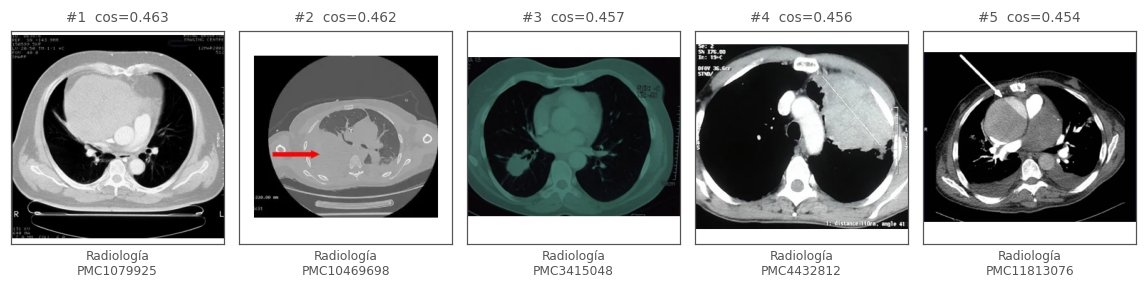


Consulta: "histopathology H&E stain showing malignant cells with high nuclear pleomorphism"
───────────────────────────────────────────────────────────────────────────────────────────


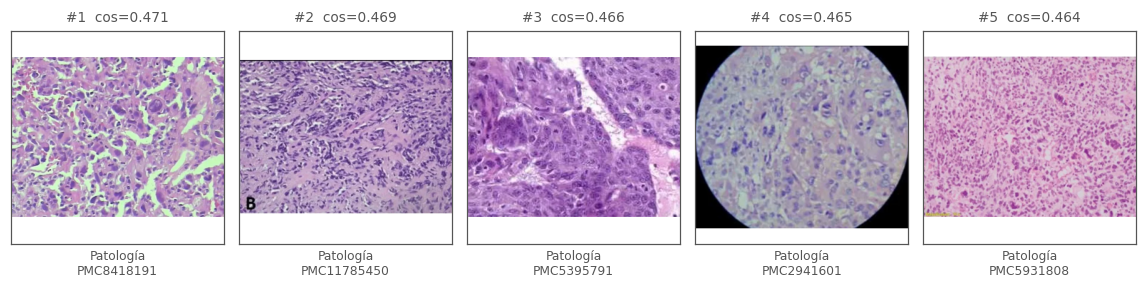


Consulta: "fundus photograph with retinal hemorrhage"
─────────────────────────────────────────────────────


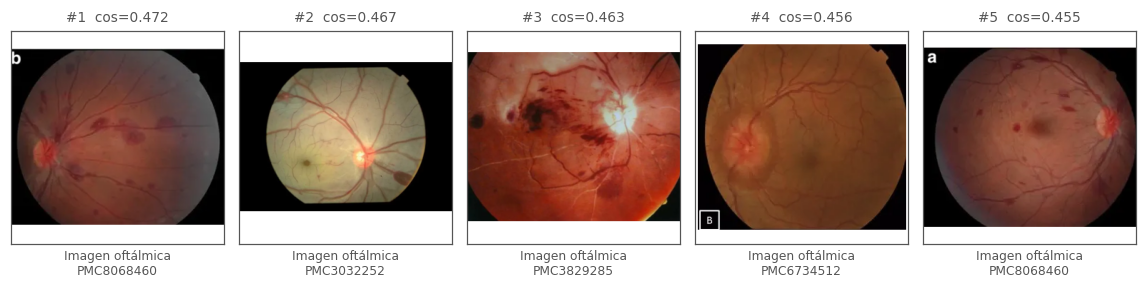

In [5]:
@torch.no_grad()
def buscar_imagenes_por_texto(consulta, k=5, solo_ccby=True):
    """Codifica texto libre y recupera las k imágenes más similares del corpus completo."""
    e = enc_txt_bio([consulta]).to(DEV)              # (1, 512) L2-normalizado
    sc = (e @ EI.T).squeeze(0)
    if solo_ccby:
        sc[~torch.from_numpy(ES_CCBY).to(DEV)] = -1e4
    top = torch.topk(sc, k)
    return top.indices.cpu().numpy(), top.values.cpu().numpy()

CONSULTAS = [
    "axial CT scan of the chest showing a large pulmonary mass",
    "histopathology H&E stain showing malignant cells with high nuclear pleomorphism",
    "fundus photograph with retinal hemorrhage",
]

for consulta in CONSULTAS:
    idx, sc = buscar_imagenes_por_texto(consulta, k=5)
    mostrar_imagenes(idx, sc, f'Consulta: "{consulta}"')


Consulta: "brain MRI showing a ring-enhancing lesion in the left frontal lobe"
──────────────────────────────────────────────────────────────────────────────


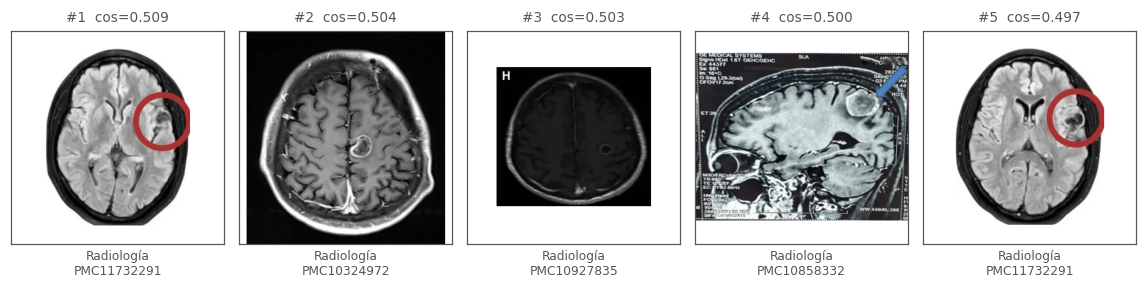

,cos,Modalidad,Subtipo,Leyenda
#,,,,
1,0.509,Radiología,mri,axial T2-weighted): Axial image showing hyperi...
2,0.504,Radiología,mri,MRI images of the patient on 3rd March.…
3,0.503,Radiología,mri,T2WI.…
4,0.500,Radiología,mri,CEMRI image showing metastatic lesion in brain...
5,0.497,Radiología,mri,FLAIR): axial image demonstrating hypointensit...


In [6]:
# ▸ Escribe aquí tu propia consulta y vuelve a ejecutar esta celda
MI_CONSULTA = "brain MRI showing a ring-enhancing lesion in the left frontal lobe"

idx, sc = buscar_imagenes_por_texto(MI_CONSULTA, k=5)
mostrar_imagenes(idx, sc, f'Consulta: "{MI_CONSULTA}"')
tabla_texto(idx, sc, {
    "Modalidad": lambda i: NOMBRE_MOD.get(imgs.image_type.iloc[i], imgs.image_type.iloc[i]),
    "Subtipo":   lambda i: imgs.image_subtype.iloc[i],
    "Leyenda":   lambda i: imgs.caption.iloc[i][:90] + "…",
})

## Demo B — Imagen → texto (I→T), con acierto y con fallo

La dirección inversa: se toma una imagen del corpus y se recuperan las leyendas más similares
entre las 130.791. El acierto exacto —la leyenda propia de esa imagen— se marca con ✓; ese es
precisamente el criterio con el que se calculó el Recall@K del manuscrito.

Como el Recall@1 de esta dirección es 0,071, la mayoría de las consultas **no** recupera su
leyenda exacta. Mostrar solo aciertos daría una impresión falsa del sistema, así que se buscan
de forma determinista el primer caso de éxito y el primero de fallo, y se examinan ambos.


Caso de ÉXITO — imagen de consulta
──────────────────────────────────


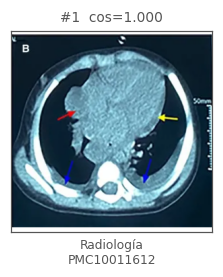

Etiqueta: ct / thorax
Leyenda correcta: posición 1


,cos,✓,Mismo caso,Leyenda recuperada
#,,,,
1,0.540,✓,sí,CT scan of chest. (B) The mediastinal window s...
2,0.477,,sí,Contrast-enhanced CT scan of chest. (B). CT sh...
3,0.466,,,(c) HRCT thorax suggestive of pericardial effu...
4,0.460,,,CT Chest:.…
5,0.452,,,CT indicated curved fluid density shadows in t...


In [7]:
@torch.no_grad()
def buscar_leyendas_por_imagen(fila_img, k=5):
    top = torch.topk(EI[fila_img] @ EC.T, k)
    return top.indices.cpu().numpy(), top.values.cpu().numpy()

# Primeras imágenes CC BY de radiología con leyenda informativa: una que acierta y una que falla
candidatas = imgs.index[(imgs.image_type == "radiology") & ES_CCBY &
                        (imgs.caption.str.len().between(80, 200))].to_numpy()
IMG_EXITO = IMG_FALLO = None
for q in candidatas[:500]:
    top, _ = buscar_leyendas_por_imagen(int(q), k=5)
    if top[0] == q and IMG_EXITO is None:
        IMG_EXITO = int(q)
    if q not in top and IMG_FALLO is None:
        IMG_FALLO = int(q)
    if IMG_EXITO is not None and IMG_FALLO is not None:
        break

def demo_i2t(fila_img, rotulo):
    mostrar_imagenes([fila_img], [1.0], rotulo)
    idx, sc = buscar_leyendas_por_imagen(fila_img, k=5)
    pos = list(idx).index(fila_img) + 1 if fila_img in idx else None
    print(f"Etiqueta: {imgs.image_subtype.iloc[fila_img]} / {imgs.radiology_region.iloc[fila_img]}")
    print(f"Leyenda correcta: {'posición ' + str(pos) if pos else 'fuera del top-5'}")
    return tabla_texto(idx, sc, {
        "✓": lambda i: "✓" if i == fila_img else "",
        "Mismo caso": lambda i: "sí" if imgs.case_idx.iloc[i] == imgs.case_idx.iloc[fila_img] else "",
        "Leyenda recuperada": lambda i: imgs.caption.iloc[i][:95] + "…",
    })

demo_i2t(IMG_EXITO, "Caso de ÉXITO — imagen de consulta")


Caso de FALLO — imagen de consulta
──────────────────────────────────


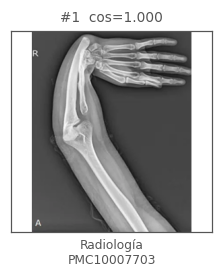

Etiqueta: x_ray / upper_limb
Leyenda correcta: fuera del top-5


,cos,✓,Mismo caso,Leyenda recuperada
#,,,,
1,0.485,,,Osseous bridging appearance between proximal a...
2,0.478,,,X-ray images of the upper limbs. . Notes: (A) ...
3,0.478,,,Plain radiographs showing soft-tissue calcific...
4,0.476,,,AP radiograph of the right forearm. A mild bow...
5,0.474,,,Plane radiographic images showing hyperostosis...


In [8]:
demo_i2t(IMG_FALLO, "Caso de FALLO — imagen de consulta")

El fallo es informativo: las leyendas recuperadas describen la misma región anatómica y el mismo
tipo de hallazgo que la consulta, pero pertenecen a otros pacientes. El sistema **sí** reconoce
el contenido clínico de la imagen; lo que no logra es discriminar entre imágenes casi
intercambiables entre sí. Esa es la diferencia entre lo que mide la métrica "identidad exacta" y
lo que busca el clínico "casos similares", y explica por qué el Recall@1 subestima la utilidad
práctica del sistema.

## Demo C — Consulta multimodal → caso clínico (TI→C)

La contribución central del trabajo: la consulta combina **una imagen y su descripción textual**,
y el sistema recupera el **caso clínico completo** entre los 33.129 casos con imagen.

Cada caso candidato se representa fusionando la media de los embeddings de sus imágenes con el
embedding de su narrativa, mediante el promedio ponderado con α = 0,75 el óptimo del barrido
reportado en el manuscrito, que pondera lo visual sin descartar lo textual.

In [9]:
ALPHA = 0.75

cases = pd.read_parquet("artifacts/cases_index.parquet")
ET = cargar("artifacts/emb_BiomedCLIP_txt.npy")      # narrativas de caso
img_case = torch.from_numpy(imgs.case_idx.to_numpy().copy()).to(DEV)

@torch.no_grad()
def representar_casos():
    """Media de los embeddings de imagen por caso, fusionada con el embedding de la narrativa."""
    d = EI.shape[1]
    sumas = torch.zeros(len(cases), d, device=DEV)
    cuenta = torch.zeros(len(cases), 1, device=DEV)
    sumas.index_add_(0, img_case, EI)
    cuenta.index_add_(0, img_case, torch.ones(N_IMG, 1, device=DEV))
    tiene = cuenta.squeeze(1) > 0
    media = torch.zeros_like(sumas)
    media[tiene] = F.normalize(sumas[tiene] / cuenta[tiene])
    return F.normalize(ALPHA * media + (1 - ALPHA) * ET), tiene

CAND_CASOS, TIENE_IMG = representar_casos()
print(f"{int(TIENE_IMG.sum()):,} casos indexados con representación multimodal")

@torch.no_grad()
def buscar_casos(fila_img, texto=None, k=5):
    """Consulta = imagen + texto (si no se da texto, se usa la leyenda de la imagen)."""
    v = EI[fila_img][None, :]
    t = enc_txt_bio([texto]).to(DEV) if texto is not None else EC[fila_img][None, :]
    q = F.normalize(ALPHA * v + (1 - ALPHA) * t)
    sc = (q @ CAND_CASOS.T).squeeze(0)
    sc[~TIENE_IMG] = -1e4
    top = torch.topk(sc, k)
    return top.indices.cpu().numpy(), top.values.cpu().numpy()

33,129 casos indexados con representación multimodal



Componente visual de la consulta
────────────────────────────────


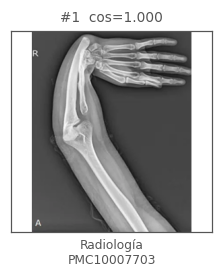

Componente textual: "Computed tomography 3D reconstruction. Of right forearm showing grossly shortened radius, deformed radius and ulna with radio ulnar dislocation.…"

Caso de origen recuperado en: posición 1

#1  cos=0.918  |  6 imágenes  |  modalidad dominante: Radiología  ✓ CASO DE ORIGEN
    Patient information: a 16-year-old female child came to the orthopaedic clinic complaining of
    weakness and tingling sensation in the right forearm since one year. The patient s mother
    noticed a deformity in the right forearm in the perinatal period. The patient had a history of
    perinatal infection of the right forearm associated with disc…

#2  cos=0.894  |  2 imágenes  |  modalidad dominante: Radiología
    A 5 years-old child fell down from a bench and a consequent blunt trauma with elbow flexion. He
    was admitted at our Trauma Center sent from other peripheric hospital, having sustained a right
    closed floating elbow. Physical examination showed closed injuries, a severe p

In [10]:
# Se reutiliza deliberadamente la imagen que FALLÓ en la Demo B: su leyenda exacta quedó fuera
# del top-5, pero la consulta multimodal sí logra recuperar su caso clínico.
CONSULTA_IMG = IMG_FALLO
CASO_CORRECTO = int(imgs.case_idx.iloc[CONSULTA_IMG])

mostrar_imagenes([CONSULTA_IMG], [1.0], "Componente visual de la consulta")
print(f'Componente textual: "{imgs.caption.iloc[CONSULTA_IMG][:160]}…"')

idx, sc = buscar_casos(CONSULTA_IMG, k=5)
print(f"\nCaso de origen recuperado en: "
      f"{'posición ' + str(list(idx).index(CASO_CORRECTO) + 1) if CASO_CORRECTO in idx else 'fuera del top-5'}")

for r, (i, s) in enumerate(zip(idx, sc), 1):
    caso = cases.iloc[i]
    marca = "  ✓ CASO DE ORIGEN" if i == CASO_CORRECTO else ""
    print(f"\n#{r}  cos={s:.3f}  |  {caso.n_images} imágenes  |  "
          f"modalidad dominante: {NOMBRE_MOD.get(caso.dom_image_type, caso.dom_image_type)}{marca}")
    print(textwrap.fill(caso.case_text[:340] + "…", width=100, initial_indent="    ",
                        subsequent_indent="    "))

Dos observaciones sobre este resultado:

- La consulta multimodal recupera el caso de origen aunque la búsqueda por leyenda sola había
  fallado sobre la misma imagen. Es exactamente el efecto que motiva la fusión: la narrativa
  completa del caso aporta contexto que la leyenda aislada no tiene.
- Los casos recuperados que **no** son el de origen tampoco son ruido: comparten modalidad,
  región anatómica y contexto clínico. Esa es la utilidad buscada, encontrar casos *similares*,
  y la métrica de identidad exacta no la captura.

## Demo D — CLIP vs. BiomedCLIP

El hallazgo principal del manuscrito es que BiomedCLIP supera a CLIP por un factor cercano a
nueve en Recall@10. Conviene ser preciso sobre **dónde** aparece esa brecha, porque no aparece
en todas las tareas:

1. **Consulta de modalidad** ("una TC de tórax"): ambos modelos aciertan. Reconocer de qué tipo
   de estudio se trata resulta ser una tarea fácil incluso para un modelo de dominio general.
2. **Recuperación a nivel de instancia** (encontrar *esta* imagen concreta entre 130.791): aquí
   sí se abre la brecha, y es la tarea que miden las métricas del manuscrito.

Se comprueban ambas: primero la comparación visual, luego un mini-benchmark en vivo sobre las
mismas consultas del protocolo de evaluación.


CLIP (dominio general) — "axial CT scan of the chest showing a large pulmonary mass"
────────────────────────────────────────────────────────────────────────────────────


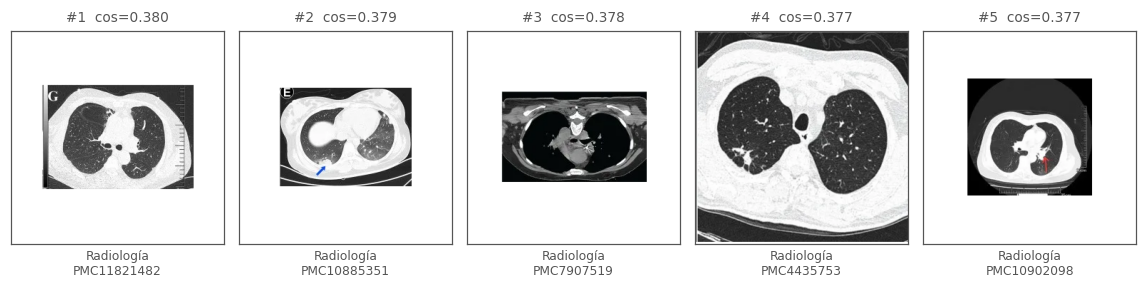

    5/5 resultados son efectivamente TC de tórax

BiomedCLIP (dominio biomédico) — "axial CT scan of the chest showing a large pulmonary mass"
────────────────────────────────────────────────────────────────────────────────────────────


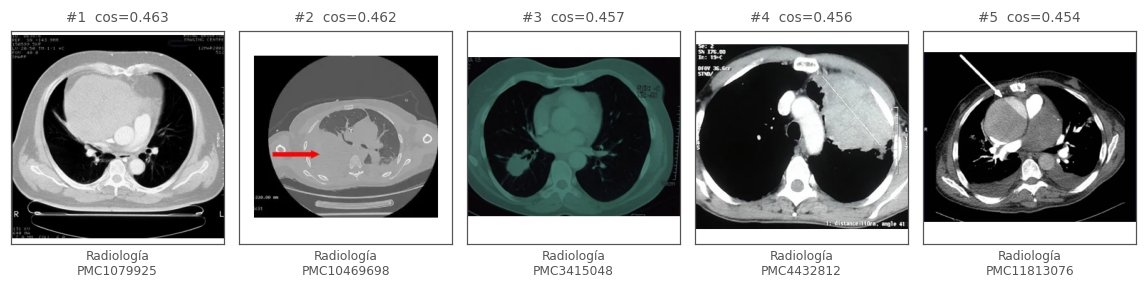

    5/5 resultados son efectivamente TC de tórax


In [11]:
HAY_CLIP = os.path.exists("artifacts/emb_CLIP_img.npy")
if not HAY_CLIP:
    print("Faltan los embeddings de CLIP. Ejecutar: python embed.py CLIP")
else:
    EI_clip = cargar("artifacts/emb_CLIP_img.npy")
    ML.DEVICE = DEV
    _, enc_txt_clip = ML.load_clip()

    @torch.no_grad()
    def buscar_con(enc_txt, banco, consulta, k=5):
        e = enc_txt([consulta]).to(DEV)
        sc = (e @ banco.T).squeeze(0)
        sc[~torch.from_numpy(ES_CCBY).to(DEV)] = -1e4
        top = torch.topk(sc, k)
        return top.indices.cpu().numpy(), top.values.cpu().numpy()

    COMPARAR = "axial CT scan of the chest showing a large pulmonary mass"
    for nombre, enc, banco in [("CLIP (dominio general)", enc_txt_clip, EI_clip),
                               ("BiomedCLIP (dominio biomédico)", enc_txt_bio, EI)]:
        i, s = buscar_con(enc, banco, COMPARAR)
        mostrar_imagenes(i, s, f'{nombre} — "{COMPARAR}"')
        ct_torax = sum((imgs.image_subtype.iloc[j] == "ct") and
                       (imgs.radiology_region.iloc[j] == "thorax") for j in i)
        print(f"    {ct_torax}/{len(i)} resultados son efectivamente TC de tórax")

In [12]:
# Mini-benchmark en vivo: recuperación a nivel de instancia (I→T) sobre las primeras 300
# consultas del mismo muestreo estratificado usado en el manuscrito (artifacts/q_it_img.npy).
if HAY_CLIP and os.path.exists("artifacts/emb_CLIP_cap.npy"):
    EC_clip = cargar("artifacts/emb_CLIP_cap.npy")
    N_BENCH = 300
    qt = torch.from_numpy(np.load("artifacts/q_it_img.npy")[:N_BENCH]).to(DEV)

    filas = []
    for nombre, Eimg, Ecap in [("CLIP", EI_clip, EC_clip), ("BiomedCLIP", EI, EC)]:
        sc = Eimg[qt] @ Ecap.T                          # (300, 130.791)
        umbral = sc.gather(1, qt[:, None]).squeeze(1)   # similitud con la leyenda correcta
        rango = (sc > umbral[:, None]).sum(1) + 1       # rango de la leyenda correcta
        filas.append({"Modelo": nombre,
                      "R@1": float((rango <= 1).float().mean()),
                      "R@10": float((rango <= 10).float().mean()),
                      "MRR": float((1 / rango.float()).mean()),
                      "Rango mediano": int(rango.median())})
        del sc

    bench = pd.DataFrame(filas).set_index("Modelo")
    display(bench.round(3))
    brecha = bench.loc["BiomedCLIP", "R@10"] / max(bench.loc["CLIP", "R@10"], 1e-9)
    print(f"Brecha medida aquí (n={N_BENCH}):  {brecha:.1f}× en Recall@10")
    print("Manuscrito (n=4.999):  CLIP 0,025  ·  BiomedCLIP 0,223  →  8,8×")
    print("\nEl rango mediano es la lectura más elocuente: la posición típica en la que cada")
    print("modelo coloca la leyenda correcta entre las 130.791 candidatas.")
else:
    print("Faltan embeddings de CLIP para el mini-benchmark.")

,R@1,R@10,MRR,Rango mediano
Modelo,,,,
CLIP,0.003,0.013,0.009,3323
BiomedCLIP,0.063,0.203,0.114,145


Brecha medida aquí (n=300):  15.2× en Recall@10
Manuscrito (n=4.999):  CLIP 0,025  ·  BiomedCLIP 0,223  →  8,8×

El rango mediano es la lectura más elocuente: la posición típica en la que cada
modelo coloca la leyenda correcta entre las 130.791 candidatas.


La brecha en el rango mediano es la lectura más clara: CLIP sitúa la leyenda correcta en torno
a la posición 3.300 de 130.791, mientras que BiomedCLIP la sitúa cerca de la 145. Ambos modelos
reconocen que se trata de una TC de tórax; solo el de dominio distingue *cuál* TC de tórax.

Nótese también que el factor medido con 300 consultas no coincide exactamente con el 8,8× del
manuscrito, calculado sobre 4.999. La diferencia es variabilidad muestral, y es un recordatorio
de que estas métricas deberían reportarse con intervalos de confianza.

## Alcance y limitaciones de la demostración

- La evaluación es **zero-shot**: ningún modelo fue ajustado sobre MultiCaRe, por lo que estos
  resultados son una cota inferior del rendimiento alcanzable.
- El componente textual de la Demo C es una **leyenda de imagen**, no una narrativa clínica
  completa; el codificador impone un límite de contexto (256 tokens en BiomedCLIP) muy inferior
  a la mediana de 2.526 caracteres de las narrativas.
- La búsqueda es por **producto interno exacto** sobre embeddings normalizados. A esta escala
  (130.791 vectores de 512 dimensiones) es instantánea en GPU y no requiere índices aproximados
  tipo FAISS.